# Import Libraries and Load Dataset

Training a neural-network inverse kinematics model for the 6-DOF robot arm.

Input:

```text
x, y, z, qx, qy, qz, qw
```

Output:

```text
j1, j2, j3, j4, j5, j6
```

In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import joblib

# Change this filename if your generated CSV has a different name
DATASET_PATH = "robot_6dof_dataset_100000.csv"

df = pd.read_csv(DATASET_PATH)
df.head()

,x,y,z,qx,qy,qz,qw,j1,j2,j3,j4,j5,j6
0,-2.329131,0.901417,0.632726,0.304408,-0.811965,0.120671,0.483206,177.277312,40.556323,-7.759785,-83.735354,60.892159,-15.149913
1,-0.998224,-2.309097,0.706872,-0.176640,-0.021707,-0.743786,0.644290,-153.118978,-16.559584,-87.209377,27.210316,12.167601,-164.417519
2,-3.080353,1.222846,-0.602774,0.377714,0.897657,-0.158633,0.162419,174.260438,4.588009,-2.062385,39.317751,-20.070234,14.442166
3,1.331950,1.163471,-1.633395,-0.846923,0.122721,0.317182,0.408725,58.129930,94.815914,-115.326219,23.616632,-18.430521,-130.522326
4,-2.329253,0.739324,1.388622,0.243079,0.362487,-0.899188,0.031263,-131.626688,28.456916,-51.113771,49.149088,-74.394015,112.140091


In [3]:
df.shape

(100000, 13)

In [4]:
df.describe()

,x,y,z,qx,qy,qz,qw,j1,j2,j3,j4,j5,j6
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,0.002921,0.983864,-0.002917,-0.001527,0.002022,0.000165,0.420692,-0.067460,59.956753,-59.876859,0.040151,-0.357114,-0.297740
std,1.355239,1.591586,1.354297,0.501473,0.500065,0.498348,0.270425,104.084009,46.187141,34.543781,51.927463,52.016521,104.018149
min,-3.452476,-2.433905,-3.453091,-0.999466,-0.999825,-0.999095,0.000002,-179.995522,-19.997785,-119.999139,-89.997336,-89.999283,-179.999297
25%,-0.973182,-0.422641,-0.980889,-0.395589,-0.393512,-0.390993,0.185687,-90.098662,19.842137,-89.724200,-45.007408,-45.391316,-90.614229
50%,0.006577,1.109119,-0.002557,0.000646,0.005486,-0.000425,0.395481,-0.344353,60.009973,-59.842708,0.145114,-0.619761,0.069730
75%,0.983993,2.449600,0.972195,0.391645,0.394817,0.390374,0.637428,90.175844,100.018200,-30.024985,44.809922,44.664449,90.172790
max,3.457308,3.740880,3.431561,0.999324,0.999936,0.999720,0.999951,179.998382,139.999157,-0.001488,89.997886,89.997165,179.995062


# Create Dataset Splits

In [5]:
# Input pose
pose_X = df[["x", "y", "z", "qx", "qy", "qz", "qw"]].values

# True joint angles
angles_deg = df[["j1", "j2", "j3", "j4", "j5", "j6"]].values

# Create seed/current angles near the target angles
np.random.seed(42)
noise = np.random.normal(loc=0.0, scale=20.0, size=angles_deg.shape)
seed_angles_deg = angles_deg + noise

# Clip seed angles to robot limits
joint_mins = np.array([-180, -20, -120, -90, -90, -180])
joint_maxs = np.array([180, 140, 0, 90, 90, 180])

seed_angles_deg = np.clip(seed_angles_deg, joint_mins, joint_maxs)

# Final input = pose + seed joint angles
X = np.concatenate([pose_X, seed_angles_deg], axis=1)

# Output = true joint angles encoded as sin/cos
angles_rad = np.deg2rad(angles_deg)

y = np.concatenate([np.sin(angles_rad), np.cos(angles_rad)], axis=1)

# Split while preserving true angle labels for evaluation
X_train, X_temp, y_train, y_temp, angles_train, angles_temp = train_test_split(
    X, y, angles_deg, test_size=0.30, random_state=42
)

X_val, X_test, y_val, y_test, angles_val, angles_test = train_test_split(
    X_temp, y_temp, angles_temp, test_size=0.50, random_state=42
)

print("Train:", len(X_train))
print("Val:", len(X_val))
print("Test:", len(X_test))
print("Input shape:", X.shape)
print("Output shape:", y.shape)


Train: 70000
Val: 15000
Test: 15000
Input shape: (100000, 13)
Output shape: (100000, 12)


### Scaling Inputs and Outputs

In [6]:
x_scaler = StandardScaler()
# y_scaler = StandardScaler()

X_train_scaled = x_scaler.fit_transform(X_train)
X_val_scaled = x_scaler.transform(X_val)
X_test_scaled = x_scaler.transform(X_test)

y_train_scaled = y_train
y_val_scaled = y_val
y_test_scaled = y_test

### Creating Tensors and DataLoaders

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train_scaled, dtype=torch.float32)

X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32).to(device)
y_val_t = torch.tensor(y_val_scaled, dtype=torch.float32).to(device)

X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)
y_test_t = torch.tensor(y_test_scaled, dtype=torch.float32).to(device)

train_dataset = TensorDataset(X_train_t, y_train_t)

train_loader = DataLoader(
    train_dataset,
    batch_size=512,
    shuffle=True
)

Using device: cuda


# Define Model

In [8]:
class IKNet6DOF(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(13, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.05),

            nn.Linear(512, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.05),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.03),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 12),
        )

    def forward(self, x):
        return self.net(x)

In [9]:
model = IKNet6DOF().to(device)

loss_fn = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-5
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=8
)

print(model)

IKNet6DOF(
  (net): Sequential(
    (0): Linear(in_features=13, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.05, inplace=False)
    (4): Linear(in_features=512, out_features=512, bias=True)
    (5): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.05, inplace=False)
    (8): Linear(in_features=512, out_features=256, bias=True)
    (9): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.03, inplace=False)
    (12): Linear(in_features=256, out_features=128, bias=True)
    (13): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU()
    (15): Linear(in_features=128, out_features=64, bias=True)
    (16): ReLU()
    (17): Linear(in_features=64, out_features=12, bias=True)
  )
)


# Train Model

In [9]:
train_losses = []
val_losses = []

best_val = float("inf")
patience = 25
counter = 0

EPOCHS = 500

for epoch in range(EPOCHS):
    model.train()

    running_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        pred = model(X_batch)
        train_loss = loss_fn(pred, y_batch)

        optimizer.zero_grad()
        train_loss.backward()
        optimizer.step()

        running_loss += train_loss.item() * X_batch.size(0)

    epoch_train_loss = running_loss / len(train_loader.dataset)

    model.eval()

    with torch.no_grad():
        val_pred = model(X_val_t)
        val_loss = loss_fn(val_pred, y_val_t)

    scheduler.step(val_loss)

    train_losses.append(epoch_train_loss)
    val_losses.append(val_loss.item())

    if epoch % 10 == 0:
        current_lr = optimizer.param_groups[0]["lr"]

        print(
            f"Epoch {epoch:3d} | "
            f"Train {epoch_train_loss:.6f} | "
            f"Val {val_loss.item():.6f} | "
            f"LR {current_lr:.6f}"
        )

    if val_loss.item() < best_val:
        best_val = val_loss.item()
        counter = 0

        torch.save(model.state_dict(), "best_robot_6dof_ik_model.pth")

    else:
        counter += 1

    if counter >= patience:
        print("Early stopping")
        break

print("Best validation loss:", best_val)

Epoch   0 | Train 0.068218 | Val 0.027104 | LR 0.001000
Epoch  10 | Train 0.016178 | Val 0.011424 | LR 0.001000
Epoch  20 | Train 0.013766 | Val 0.009414 | LR 0.001000
Epoch  30 | Train 0.012520 | Val 0.009049 | LR 0.001000
Epoch  40 | Train 0.010725 | Val 0.007134 | LR 0.000500
Epoch  50 | Train 0.009414 | Val 0.006215 | LR 0.000250
Epoch  60 | Train 0.009151 | Val 0.006303 | LR 0.000250
Epoch  70 | Train 0.008863 | Val 0.006124 | LR 0.000250
Epoch  80 | Train 0.008346 | Val 0.005794 | LR 0.000125
Epoch  90 | Train 0.008113 | Val 0.005625 | LR 0.000125
Epoch 100 | Train 0.007664 | Val 0.005390 | LR 0.000063
Epoch 110 | Train 0.007572 | Val 0.005364 | LR 0.000031
Epoch 120 | Train 0.007541 | Val 0.005322 | LR 0.000031
Epoch 130 | Train 0.007423 | Val 0.005304 | LR 0.000031
Epoch 140 | Train 0.007444 | Val 0.005329 | LR 0.000031
Epoch 150 | Train 0.007363 | Val 0.005304 | LR 0.000031
Epoch 160 | Train 0.007288 | Val 0.005219 | LR 0.000016
Epoch 170 | Train 0.007290 | Val 0.005256 | LR 0

# Plot Training Curve

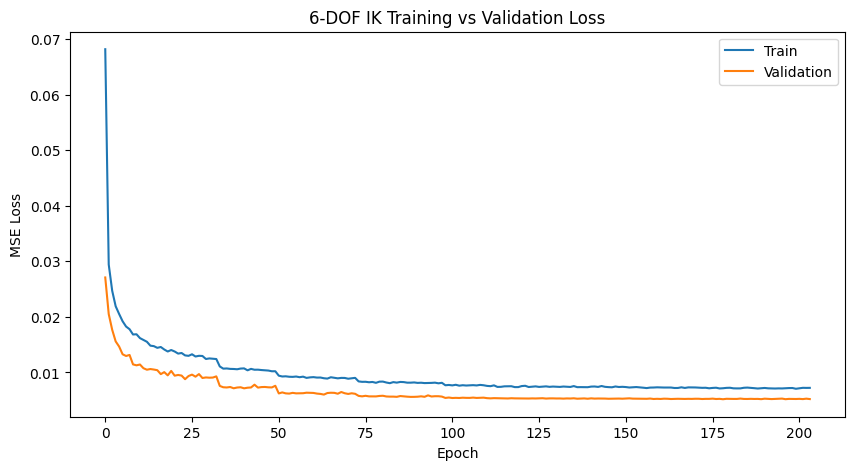

In [10]:
plt.figure(figsize=(10, 5))

plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Validation")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("6-DOF IK Training vs Validation Loss")
plt.legend()

plt.show()

# Evaluate on Test Set

In [10]:
def sincos_to_angles_deg(y_pred):
    sin_vals = y_pred[:, :6]
    cos_vals = y_pred[:, 6:]

    angles_rad = np.arctan2(sin_vals, cos_vals)
    angles_deg = np.rad2deg(angles_rad)

    return angles_deg

def angular_error_deg(pred, true):
    return np.abs((pred - true + 180) % 360 - 180)

In [11]:
model.load_state_dict(torch.load("best_robot_6dof_ik_model.pth", map_location=device))
model.eval()

with torch.no_grad():
    pred_test_sincos = model(X_test_t)
    test_loss = loss_fn(pred_test_sincos, y_test_t)

print("Sincos test loss:", test_loss.item())


C:\Users\shivo\AppData\Local\Temp\ipykernel_30412\119751821.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_robot_6dof_ik_model.pt

Sincos test loss: 0.005221604835242033


In [12]:
pred_sincos_np = pred_test_sincos.detach().cpu().numpy()

pred_angles = sincos_to_angles_deg(pred_sincos_np)

# IMPORTANT:
# angles_test must come from the train_test_split
# It should contain the original raw angles in degrees
true_angles = angles_test

angle_errors = angular_error_deg(pred_angles, true_angles)

mae_per_joint = angle_errors.mean(axis=0)
max_error_per_joint = angle_errors.max(axis=0)

for i in range(6):
    print(f"Joint {i + 1} MAE: {mae_per_joint[i]:.3f} degrees")
    print(f"Joint {i + 1} Max Error: {max_error_per_joint[i]:.3f} degrees")
    print()

print("Overall MAE:", angle_errors.mean(), "degrees")


Joint 1 MAE: 2.413 degrees
Joint 1 Max Error: 47.056 degrees

Joint 2 MAE: 2.750 degrees
Joint 2 Max Error: 19.947 degrees

Joint 3 MAE: 4.812 degrees
Joint 3 Max Error: 37.340 degrees

Joint 4 MAE: 5.667 degrees
Joint 4 Max Error: 52.242 degrees

Joint 5 MAE: 2.540 degrees
Joint 5 Max Error: 35.627 degrees

Joint 6 MAE: 4.811 degrees
Joint 6 Max Error: 52.639 degrees

Overall MAE: 3.832129387978394 degrees


In [13]:
# FK Task-Space Evaluation
# This checks whether predicted angles actually reach the target pose.

ROBOT = {
    "BASE_HEIGHT": 0.25,
    "UPPER_ARM_LENGTH": 1.2,
    "FOREARM_LENGTH": 1.0,
    "WRIST_LENGTH": 0.45,
    "TOOL_LENGTH": 0.35,
    "TCP_OFFSET": 0.5,
}


def rot_x(a):
    c, s = np.cos(a), np.sin(a)
    return np.array(
        [
            [1, 0, 0, 0],
            [0, c, -s, 0],
            [0, s, c, 0],
            [0, 0, 0, 1],
        ]
    )


def rot_y(a):
    c, s = np.cos(a), np.sin(a)
    return np.array(
        [
            [c, 0, s, 0],
            [0, 1, 0, 0],
            [-s, 0, c, 0],
            [0, 0, 0, 1],
        ]
    )


def rot_z(a):
    c, s = np.cos(a), np.sin(a)
    return np.array(
        [
            [c, -s, 0, 0],
            [s, c, 0, 0],
            [0, 0, 1, 0],
            [0, 0, 0, 1],
        ]
    )


def trans(x, y, z):
    T = np.eye(4)
    T[:3, 3] = [x, y, z]
    return T


def fk_python(joint_angles_deg):
    j1, j2, j3, j4, j5, j6 = np.deg2rad(joint_angles_deg)

    T = np.eye(4)

    T = T @ trans(0, ROBOT["BASE_HEIGHT"], 0)
    T = T @ rot_y(j1)
    T = T @ rot_z(j2)
    T = T @ trans(ROBOT["UPPER_ARM_LENGTH"], 0, 0)
    T = T @ rot_z(j3)
    T = T @ trans(ROBOT["FOREARM_LENGTH"], 0, 0)
    T = T @ rot_z(j4)
    T = T @ trans(ROBOT["WRIST_LENGTH"], 0, 0)
    T = T @ rot_y(j5)
    T = T @ trans(ROBOT["TOOL_LENGTH"], 0, 0)
    T = T @ rot_x(j6)
    T = T @ trans(ROBOT["TCP_OFFSET"], 0, 0)

    position = T[:3, 3]
    rotation = T[:3, :3]

    return position, rotation


def rotation_matrix_to_quaternion(R):
    q = np.empty(4)

    trace = np.trace(R)

    if trace > 0:
        s = 0.5 / np.sqrt(trace + 1.0)
        q[3] = 0.25 / s
        q[0] = (R[2, 1] - R[1, 2]) * s
        q[1] = (R[0, 2] - R[2, 0]) * s
        q[2] = (R[1, 0] - R[0, 1]) * s
    else:
        if R[0, 0] > R[1, 1] and R[0, 0] > R[2, 2]:
            s = 2.0 * np.sqrt(1.0 + R[0, 0] - R[1, 1] - R[2, 2])
            q[3] = (R[2, 1] - R[1, 2]) / s
            q[0] = 0.25 * s
            q[1] = (R[0, 1] + R[1, 0]) / s
            q[2] = (R[0, 2] + R[2, 0]) / s
        elif R[1, 1] > R[2, 2]:
            s = 2.0 * np.sqrt(1.0 + R[1, 1] - R[0, 0] - R[2, 2])
            q[3] = (R[0, 2] - R[2, 0]) / s
            q[0] = (R[0, 1] + R[1, 0]) / s
            q[1] = 0.25 * s
            q[2] = (R[1, 2] + R[2, 1]) / s
        else:
            s = 2.0 * np.sqrt(1.0 + R[2, 2] - R[0, 0] - R[1, 1])
            q[3] = (R[1, 0] - R[0, 1]) / s
            q[0] = (R[0, 2] + R[2, 0]) / s
            q[1] = (R[1, 2] + R[2, 1]) / s
            q[2] = 0.25 * s

    if q[3] < 0:
        q = -q

    return q


def quaternion_error_rad(q_pred, q_true):
    dot = np.abs(np.dot(q_pred, q_true))
    dot = np.clip(dot, -1.0, 1.0)
    return 2 * np.arccos(dot)


position_errors = []
orientation_errors = []

target_positions = X_test[:, :3]
target_quaternions = X_test[:, 3:7]

for i in range(len(pred_angles)):
    pred_pos, pred_rot = fk_python(pred_angles[i])
    pred_quat = rotation_matrix_to_quaternion(pred_rot)

    pos_error = np.linalg.norm(pred_pos - target_positions[i])
    ori_error = quaternion_error_rad(pred_quat, target_quaternions[i])

    position_errors.append(pos_error)
    orientation_errors.append(ori_error)

position_errors = np.array(position_errors)
orientation_errors = np.array(orientation_errors)

print("FK Position Error")
print("Mean:", position_errors.mean())
print("Median:", np.median(position_errors))
print("Max:", position_errors.max())

print("\nFK Orientation Error")
print("Mean radians:", orientation_errors.mean())
print("Median radians:", np.median(orientation_errors))
print("Mean degrees:", np.rad2deg(orientation_errors.mean()))
print("Median degrees:", np.rad2deg(np.median(orientation_errors)))
print("Max degrees:", np.rad2deg(orientation_errors.max()))


FK Position Error
Mean: 0.10725172230766293
Median: 0.09709541831257733
Max: 0.6507131975070324

FK Orientation Error
Mean radians: 0.0839159274191496
Median radians: 0.07606576778865987
Mean degrees: 4.8080284750434155
Median degrees: 4.358247459712375
Max degrees: 27.137315546694918


# Quick Prediction Function

In [14]:
def predict_angles(pose, seed_angles):
    """
    pose format:
    [x, y, z, qx, qy, qz, qw]

    seed_angles format:
    [j1, j2, j3, j4, j5, j6]
    """

    model.eval()

    pose = np.array(pose).reshape(1, -1)
    seed_angles = np.array(seed_angles).reshape(1, -1)

    model_input = np.concatenate([pose, seed_angles], axis=1)
    model_input_scaled = x_scaler.transform(model_input)

    input_t = torch.tensor(model_input_scaled, dtype=torch.float32).to(device)

    with torch.no_grad():
        pred_sincos = model(input_t).cpu().numpy()

    pred_angles = sincos_to_angles_deg(pred_sincos)

    return pred_angles[0]



sample_index = 0

sample_input = X_test[sample_index]
sample_pose = sample_input[:7]
sample_seed = sample_input[7:]

true_angles_sample = angles_test[sample_index]

predicted_angles = predict_angles(sample_pose, sample_seed)

sample_error = angular_error_deg(
    predicted_angles.reshape(1, -1), true_angles_sample.reshape(1, -1)
)[0]

print("Pose:")
print(sample_pose)

print("\nSeed angles:")
print(sample_seed)

print("\nTrue angles:")
print(true_angles_sample)

print("\nPredicted angles:")
print(predicted_angles)

print("\nCircular absolute error:")
print(sample_error)

Pose:
[ 0.85728461  2.73000538 -0.07349839  0.90441709  0.19578697 -0.08298013
  0.36988038]

Seed angles:
[143.03968092  96.05390167 -40.92849117  71.89266672 -65.41933696
  -0.44446608]

True angles:
[115.40461253 121.57598574 -68.98156081  60.32714525 -71.46648949
  18.76684913]

Predicted angles:
[127.31958  107.88515  -53.37585   83.97766  -63.033394 -10.869989]

Circular absolute error:
[11.91496755 13.69083865 15.60571013 23.65051588  8.43309563 29.63683853]


# Save Model and Scalers

In [15]:
torch.save(model.state_dict(), "robot_6dof_ik_nn.pth")

joblib.dump(x_scaler, "x_scaler_6dof.pkl")
# joblib.dump(y_scaler, "y_scaler_6dof.pkl")  

print("Saved:")
print("robot_6dof_ik_nn.pth")
print("x_scaler_6dof.pkl")

Saved:
robot_6dof_ik_nn.pth
x_scaler_6dof.pkl


# Important Note

This dataset is generated using forward kinematics:

```text
joint angles -> FK -> pose
```

The neural network learns the inverse approximation:

```text
pose -> joint angles
```

For 6-DOF robots, multiple joint configurations can sometimes produce the same or similar end-effector pose. Using full pose input with quaternion orientation reduces ambiguity compared to position-only IK.